In [1]:
import igl
import scipy as sp
import numpy as np
from meshplot import plot, subplot, interact
import open3d as o3d
from mesh_processing import *

import os
root_folder = os.getcwd()




shape_name = 'SimpleHuman'


# Paths

off_filepath = f"data/surfaces/{shape_name}.off"
obj_filepath = f"data/surfaces/{shape_name}.obj"
manual_coarse_filepath = f"data/surfaces/{shape_name}-coarse-m.obj"

# Check if .off file exists
if not os.path.exists(off_filepath):
    if os.path.exists(obj_filepath):
        print(f"{off_filepath} not found. Converting from .obj...")
        mesh = o3d.io.read_triangle_mesh(obj_filepath)
    else:
        raise FileNotFoundError(f"Neither {off_filepath} nor {obj_filepath} found.")
else:
    mesh = o3d.io.read_triangle_mesh(off_filepath)

# Normalize the mesh
mesh.vertex_normals = o3d.utility.Vector3dVector()  # Clear vertex normals
mesh.triangle_normals = o3d.utility.Vector3dVector()  # Clear triangle normals
mesh = normalise_to_unit_bbox(mesh)

# Overwrite both .off and .obj with normalized mesh
o3d.io.write_triangle_mesh(off_filepath, mesh)
o3d.io.write_triangle_mesh(obj_filepath, mesh)

print(f"Normalized mesh saved to {off_filepath} and {obj_filepath}.")




v, f = igl.read_triangle_mesh(os.path.join(root_folder, "data", "surfaces/SimpleHuman.obj"))
#v[:,[0, 2]] = v[:,[2, 0]] # Swap X and Z axes
u = v.copy()


print(v.shape)


num_vertices = v.shape[0]
s = -1 * np.ones((num_vertices, 1), dtype=int)

def in_ball(x, x0=np.array([0,0,0]), r=0.01):
    return ((x-x0)**2).sum(-1)<r**2

keypoint_mask_dict = {

'foot1' :  np.where(in_ball(v, x0=np.array([-0.169945, -0.480926, 0.046845])))[0],
'foot2' :  np.where(in_ball(v, x0=np.array([0.169945, -0.480926, 0.046845])))[0],
    
    'hand1' :  np.where(in_ball(v, x0=np.array([-0.279367, -0.028232, 0.085358])))[0],
    'hand2' :  np.where(in_ball(v, x0=np.array([0.279367, -0.028232, 0.085358])))[0],

    'head' :  np.where(in_ball(v, x0=np.array([-0.004036, 0.498832, -0.005143])))[0],

    'shoulder1': np.where(in_ball(v, x0=np.array([-0.109898, 0.323125, -0.036819])))[0],
    'shoulder2': np.where(in_ball(v, x0=np.array([0.109898, 0.323125, -0.036819])))[0],

    'bum': np.where(in_ball(v, x0=np.array([0.0, 0.020522, -0.050593])))[0]

}

# Assign handle IDs (0 to len(mask)-1) to those selected vertices
keypoint_idx_dict = dict()
keypoint_coord_dict = dict()

i=0
for key,mask in keypoint_mask_dict.items():
    keypoint_idx_dict[key] = i
    s[mask] = i

    keypoint_coord_dict[key] = np.mean(v[mask,:], axis=0)
    i+=1




b = np.array([[t[0] for t in [(i, s[i]) for i in range(0, v.shape[0])] if t[1] >= 0]]).T

## Boundary conditions directly on deformed positions
u_bc = np.zeros((b.shape[0], v.shape[1]))
v_bc = np.zeros((b.shape[0], v.shape[1]))

for bi in range(b.shape[0]):
    v_bc[bi] = v[b[bi]]

    
    if s[b[bi]] == 0: # Move other handles forward
        u_bc[bi] = v[b[bi]] + np.array([[1,0,0]])
    elif s[b[bi]] == 1: # Move other handles forward
        u_bc[bi] = v[b[bi]] - np.array([[2,0,0]])
    elif s[b[bi]] == 2: # head stays still
        u_bc[bi] = v[b[bi]]

plot(v, f, s, shading={"wireframe": False, "colormap": "tab10"})

1.0
[Open3D WARNING] Write OFF cannot include triangle normals.
[Open3D WARNING] Write OBJ can not include triangle normals.
Normalized mesh saved to data/surfaces/SimpleHuman.off and data/surfaces/SimpleHuman.obj.
(9143, 3)


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

In [2]:
def rot_x(theta):
    """Rotation matrix around the X-axis"""
    return np.array([
        [1, 0, 0],
        [0, np.cos(theta), -np.sin(theta)],
        [0, np.sin(theta),  np.cos(theta)]
    ])

def rot_y(theta):
    """Rotation matrix around the Y-axis"""
    return np.array([
        [ np.cos(theta), 0, np.sin(theta)],
        [ 0,            1, 0           ],
        [-np.sin(theta), 0, np.cos(theta)]
    ])

def rot_z(theta):
    """Rotation matrix around the Z-axis"""
    return np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0,             0,              1]
    ])

    


# Correct b shape
b = np.array([i for i in range(v.shape[0]) if s[i] >= 0]) #determines which indices 'fixed' (not dofs)



# Precompute ARAP
arap = igl.ARAP(v, f, 3, b)

@interact(t=(0.0, 1.0), w=(0.25, 4.0))
def update(t=0.0, w=1.0):
    bc = np.zeros((b.size, v.shape[1]))
    for i in range(b.size):
        bc[i] = v[b[i]]
        
        if s[b[i]] == keypoint_idx_dict['foot1']:
            bc[i] = keypoint_coord_dict['bum'] + rot_z(-t * np.pi/4) @ ( v[b[i]] - keypoint_coord_dict['bum'] )
            
        if s[b[i]] == keypoint_idx_dict['foot2']:
            bc[i] = keypoint_coord_dict['bum'] + rot_z(t * np.pi/4) @ ( v[b[i]] - keypoint_coord_dict['bum'] )

        elif s[b[i]] == keypoint_idx_dict['hand2']:
            bc[i] = keypoint_coord_dict['shoulder2'] + rot_x( -t * np.pi/4) @ ( v[b[i]] - keypoint_coord_dict['shoulder2'] )
            
        elif s[b[i]] == keypoint_idx_dict['hand1']:
            bc[i] = keypoint_coord_dict['shoulder1'] + rot_z( -t * np.pi/8) @ ( v[b[i]] - keypoint_coord_dict['shoulder1'] )

        elif s[b[i]] == keypoint_idx_dict['head']:
            bc[i] = (v[b[i]] - keypoint_coord_dict['head']) *w + keypoint_coord_dict['head']

    
    vn = arap.solve(bc, v)

    
    # Combine vertices
    '''
    V_combined = np.vstack([u, vn])
    # Offset the face indices of the second mesh
    F_combined = np.vstack([f, f + u.shape[0]])
    plot(V_combined, F_combined, np.vstack([s,s]), shading={"wireframe": False, "colormap": "tab10"})
    '''
    plot(vn, f, s, shading={"wireframe": False, "colormap": "tab10"})


interactive(children=(FloatSlider(value=0.0, description='t', max=1.0), FloatSlider(value=1.0, description='w'…

In [3]:
# GLOBAL: to store camera state between updates
camera_state = {"position": None, "target": None, "zoom": None}

# Initialize plot once (global handle)
initial_vn = v.copy()  # use original as placeholder
p = plot(initial_vn, f, s, shading={"wireframe": False, "colormap": "tab10"})

@interact(
    foot1_rot=(-1.0, 1.0, 0.01),
    foot2_rot=(-1.0, 1.0, 0.01),
    hand1_rot=(-1.0, 1.0, 0.01),
    hand2_rot=(-1.0, 1.0, 0.01),
    head_scale=(0.5, 2.0, 0.01)
)
def update(foot1_rot=0.0, foot2_rot=0.0, hand1_rot=0.0, hand2_rot=0.0, head_scale=1.0):
    global p, camera_state

    # Store current camera settings
    if p._cam:
        camera_state["position"] = list(p._cam.position)
        camera_state["zoom"] = p._cam.zoom
        camera_state["target"] = list(p._orbit.target)

    # Compute new deformation
    bc = np.zeros((b.size, v.shape[1]))
    for i in range(b.size):
        bc[i] = v[b[i]]
        if s[b[i]] == keypoint_idx_dict['foot1']:
            bc[i] = keypoint_coord_dict['bum'] + rot_z(foot1_rot * np.pi/4) @ (v[b[i]] - keypoint_coord_dict['bum'])
        elif s[b[i]] == keypoint_idx_dict['foot2']:
            bc[i] = keypoint_coord_dict['bum'] + rot_z(foot2_rot * np.pi/4) @ (v[b[i]] - keypoint_coord_dict['bum'])
        elif s[b[i]] == keypoint_idx_dict['hand2']:
            bc[i] = keypoint_coord_dict['shoulder2'] + rot_x(hand2_rot * np.pi/4) @ (v[b[i]] - keypoint_coord_dict['shoulder2'])
        elif s[b[i]] == keypoint_idx_dict['hand1']:
            bc[i] = keypoint_coord_dict['shoulder1'] + rot_z(hand1_rot * np.pi/8) @ (v[b[i]] - keypoint_coord_dict['shoulder1'])
        elif s[b[i]] == keypoint_idx_dict['head']:
            bc[i] = (v[b[i]] - keypoint_coord_dict['head']) * head_scale + keypoint_coord_dict['head']

    vn = arap.solve(bc, v)

    # Update the mesh geometry directly (instead of replotting)
    p.update_object(vertices=vn)

    # Re-apply previous camera
    if camera_state["position"]:
        p._cam.position = camera_state["position"]
        p._cam.zoom = camera_state["zoom"]
        p._orbit.target = camera_state["target"]


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

interactive(children=(FloatSlider(value=0.0, description='foot1_rot', max=1.0, min=-1.0, step=0.01), FloatSlid…

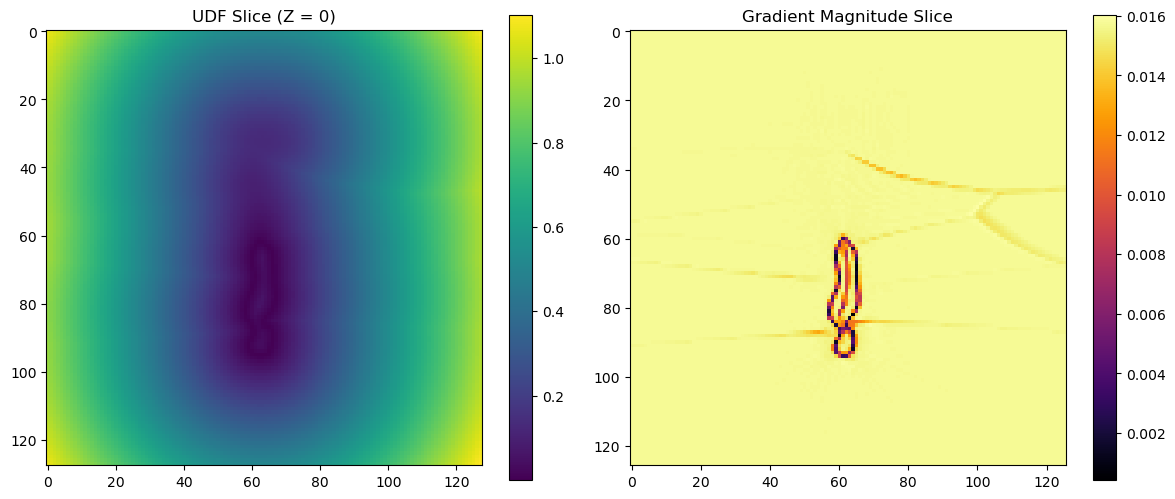

In [ ]:
import numpy as np
import open3d as o3d
import torch
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt

# === Load Mesh ===
mesh = o3d.io.read_triangle_mesh(obj_filepath)
mesh.compute_vertex_normals()
pcd = mesh.sample_points_uniformly(number_of_points=50000)
surface_points = np.asarray(pcd.points)

# === Create Voxel Grid ===
grid_res = 128
x = y = z = np.linspace(-1, 1, grid_res)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
voxel_points = np.vstack((X.ravel(), Y.ravel(), Z.ravel())).astype(np.float32).transpose(1,0)

# === Compute UDF with cKDTree ===
tree = cKDTree(surface_points)
udf, _ = tree.query(voxel_points, k=1)
udf_grid = udf.reshape((grid_res, grid_res, grid_res)).astype(np.float32)

# === Compute Gradient (Central Differences) ===
udf_tensor = torch.from_numpy(udf_grid).unsqueeze(0).unsqueeze(0)  # shape (1, 1, D, H, W)

# Use PyTorch gradient to compute gradient field
def compute_gradient(tensor):
    # Central differences on all 3 axes
    dx = (tensor[:, :, 1:-1, 1:-1, 2:] - tensor[:, :, 1:-1, 1:-1, :-2]) / 2
    dy = (tensor[:, :, 1:-1, 2:, 1:-1] - tensor[:, :, 1:-1, :-2, 1:-1]) / 2
    dz = (tensor[:, :, 2:, 1:-1, 1:-1] - tensor[:, :, :-2, 1:-1, 1:-1]) / 2
    return dx.squeeze(), dy.squeeze(), dz.squeeze()


dx, dy, dz = compute_gradient(udf_tensor)

# === Visualize Slices of UDF ===
slice_idx = grid_res // 2
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(udf_grid[slice_idx], cmap='viridis')
plt.title("UDF Slice (Z = 0)")
plt.colorbar()

plt.subplot(1, 2, 2)
grad_mag = np.sqrt(dx**2 + dy**2 + dz**2).numpy()
plt.imshow(grad_mag[slice_idx], cmap='inferno')
plt.title("Gradient Magnitude Slice")
plt.colorbar()
plt.tight_layout()
plt.show()
# === Crop voxel grid and UDF to match gradient shape ===
udf_inner = udf_grid[1:-1, 1:-1, 1:-1]
X_inner = X[1:-1, 1:-1, 1:-1]
Y_inner = Y[1:-1, 1:-1, 1:-1]
Z_inner = Z[1:-1, 1:-1, 1:-1]

# Convert gradients to numpy
dx_np = dx.numpy()
dy_np = dy.numpy()
dz_np = dz.numpy()

# === Filter: only show arrows close to the surface ===
udf_threshold = 0.02  # distance threshold (in same units as voxel grid)
mask = udf_inner < udf_threshold  # shape: (D-2, H-2, W-2)

# Optionally subsample with stride
stride = 2
mask[::stride, ::stride, ::stride] &= True  # downsample

# Get coordinates and gradients where mask is True
coords = np.vstack((
    X_inner[mask],
    Y_inner[mask],
    Z_inner[mask]
)).T

grads = np.vstack((
    dx_np[mask],
    dy_np[mask],
    dz_np[mask]
)).T

# Normalize and scale vectors
grads /= np.linalg.norm(grads, axis=1, keepdims=True) + 1e-8
grads *= 0.05  # scale for visibility

# === Create LineSet for visualization ===
line_points = []
lines = []
line_colors = []

for i in range(coords.shape[0]):
    p1 = coords[i]
    p2 = p1 + grads[i]
    idx = len(line_points)
    line_points.extend([p1, p2])
    lines.append([idx, idx + 1])
    line_colors.append([1, 0, 0])  # red

line_set = o3d.geometry.LineSet()
line_set.points = o3d.utility.Vector3dVector(line_points)
line_set.lines = o3d.utility.Vector2iVector(lines)
line_set.colors = o3d.utility.Vector3dVector(line_colors)

# Also show the mesh or point cloud
pcd.paint_uniform_color([0, 1, 0])
o3d.visualization.draw_geometries([line_set, pcd])


In [20]:
dy.shape, dz.shape, dx.shape

(torch.Size([62, 62, 62]), torch.Size([62, 62, 62]), torch.Size([62, 62, 62]))